<a href="https://colab.research.google.com/github/Wachmercy/Wachmercy/blob/main/Crop_pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install openml


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 40.2 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=40a4705906009c3d8ecfd5720e4e93992e83cbb269326b9af06d84cd569ea382
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [8]:
import pandas as pd
import openml

dataset_id = 1596  # Worldwide Crop Production Dataset

try:
    crop_dataset = openml.datasets.get_dataset(dataset_id, download_all_files=True)
    X, y, categorical_indicator, attribute_names = crop_dataset.get_data(target=None)
    df = pd.DataFrame(X, columns=attribute_names)
    print("Dataset successfully loaded!")
    print(df.head())
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")


/tmp/ipython-input-2243945113.py:7: FutureWarning: ``download_all_files`` is experimental and is likely to break with new releases.
  crop_dataset = openml.datasets.get_dataset(dataset_id, download_all_files=True)


Dataset successfully loaded!
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0     2596.0    51.0      3                             258.0   
1     2590.0    56.0      2                             212.0   
2     2804.0   139.0      9                             268.0   
3     2785.0   155.0     18                             242.0   
4     2595.0    45.0      2                             153.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                             0.0                            510.0   
1                            -6.0                            390.0   
2                            65.0                           3180.0   
3                           118.0                           3090.0   
4                            -1.0                            391.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2     

In [9]:
# ===============================
# Zero Hunger Project: Crop Yields
# ===============================

# Step 1: Install and import libraries
!pip install openml --quiet
import pandas as pd
import openml
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the OpenML Crop Production Dataset
dataset_id = 1596  # Worldwide Crop Production Dataset

try:
    crop_dataset = openml.datasets.get_dataset(dataset_id, download_all_files=True)
    X, y, categorical_indicator, attribute_names = crop_dataset.get_data(target=None)
    df = pd.DataFrame(X, columns=attribute_names)
    print("✅ Dataset successfully loaded!")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

# Step 3: Inspect the dataset
print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Dataset shape ---")
print(df.shape)

print("\n--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Data types ---")
print(df.dtypes)

# Step 4: Basic statistics
print("\n--- Summary statistics ---")
print(df.describe())

# Step 5: Analyze crop yields (example)
if 'crop' in df.columns and 'yield' in df.columns:
    avg_yield = df.groupby('crop')['yield'].mean().sort_values(ascending=False)
    print("\n--- Average Yield per Crop ---")
    print(avg_yield)

    # Step 6: Visualize crop yields
    plt.figure(figsize=(12,6))
    sns.barplot(x=avg_yield.index, y=avg_yield.values, palette="viridis")
    plt.xticks(rotation=45)
    plt.title("Average Yield per Crop")
    plt.ylabel("Yield")
    plt.xlabel("Crop")
    plt.show()

# Step 7: Additional analysis (optional)
# Example: correlation between yield and arable land
if 'arable_land_area' in df.columns and 'yield' in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x='arable_land_area', y='yield')
    plt.title("Yield vs Arable Land Area")
    plt.xlabel("Arable Land Area")
    plt.ylabel("Yield")
    plt.show()


/tmp/ipython-input-118249733.py:16: FutureWarning: ``download_all_files`` is experimental and is likely to break with new releases.
  crop_dataset = openml.datasets.get_dataset(dataset_id, download_all_files=True)


✅ Dataset successfully loaded!

--- First 5 rows ---
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0     2596.0    51.0      3                             258.0   
1     2590.0    56.0      2                             212.0   
2     2804.0   139.0      9                             268.0   
3     2785.0   155.0     18                             242.0   
4     2595.0    45.0      2                             153.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                             0.0                            510.0   
1                            -6.0                            390.0   
2                            65.0                           3180.0   
3                           118.0                           3090.0   
4                            -1.0                            391.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235 

✅ Random Forest Classifier Model Trained Successfully!
Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     42557
           2       0.96      0.97      0.96     56500
           3       0.95      0.96      0.95      7121
           4       0.91      0.83      0.87       526
           5       0.95      0.79      0.86      1995
           6       0.93      0.90      0.92      3489
           7       0.98      0.95      0.96      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.96    116203


Confusion Matrix:
[[40693  1788     0     0    10     4    62]
 [ 1382 54882    79     0    75    64    18]
 [    2   159  6802    27     3   128     0]
 [    0     1    64   435     0    26     0]
 [   22   377    17     0  1572     7     0]
 [    1   119   210    16     3  3140     0]
 [  184    16     0 

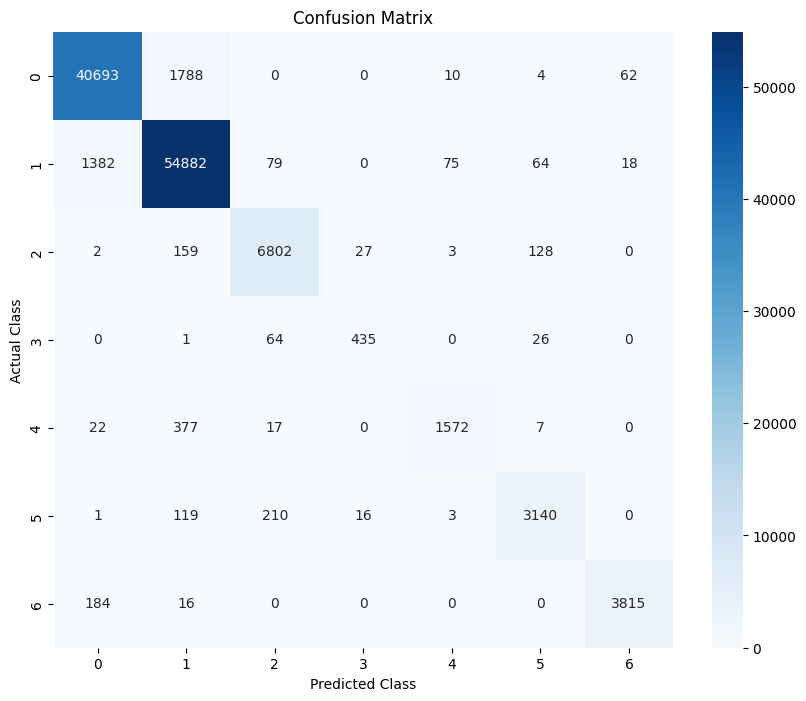

In [12]:
# ===============================
# Step 8: Crop Yield Prediction
# ===============================

# Step 8.1: Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier # Since 'class' is likely categorical

# Step 8.2: Select features and target
# Here we assume 'class' is the target, and we select numeric features
target = 'class'
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if target in features:
    features.remove(target)  # Remove target from features

X = df[features]
y = df[target]

# Step 8.3: Handle missing values (simple imputation)
X = X.fillna(X.mean())
y = y.fillna(y.mode()[0]) # Use mode for categorical target

# Step 8.4: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8.5: Initialize and train a classification model (since target is 'class')
# Using RandomForestClassifier as it's suitable for classification
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 8.6: Make predictions
y_pred = model.predict(X_test)

# Step 8.7: Evaluate the model
# For classification, we can use accuracy score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("✅ Random Forest Classifier Model Trained Successfully!")
print(f"Accuracy: {accuracy:.2f}")

# Optional: Print classification report and confusion matrix for more detailed evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Step 8.8: Visualize predictions vs actual values (Optional for classification)
# A confusion matrix is a better visualization for classification
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# New Section